In [4]:
import numpy as np


def phase_Appro(x: np.complex64):
    z = x.imag / x.real
    return np.pi / 4 * z - 0.7233 * z * (1 - np.abs(z))


for i in range(30):
    x = np.exp(1j * (np.pi / 2 / 60 * i))
    print(x, phase_Appro(x), np.angle(x, deg=False))

(1+0j) 0.0 0.0
(0.9996573249755573+0.02617694830787315j) 0.002122066246195823 0.02617993877991494
(0.9986295347545738+0.05233595624294383j) 0.005241024776956225 0.05235987755982988
(0.996917333733128+0.07845909572784494j) 0.009367321746739578 0.07853981633974483
(0.9945218953682733+0.10452846326765346j) 0.014517002941148924 0.10471975511965977
(0.9914448613738104+0.13052619222005157j) 0.020711888848383042 0.1308996938995747
(0.9876883405951378+0.15643446504023087j) 0.027979819711558218 0.15707963267948966
(0.9832549075639546+0.18223552549214744j) 0.03635497548410266 0.18325957145940458
(0.9781476007338057+0.20791169081775931j) 0.04587827723555142 0.2094395102393195
(0.9723699203976766+0.2334453638559054j) 0.05659787838870928 0.23561944901923448
(0.9659258262890683+0.25881904510252074j) 0.06856975627552636 0.2617993877991494
(0.958819734868193+0.2840153447039226j) 0.08185841695516496 0.28797932657906433
(0.9510565162951535+0.3090169943749474j) 0.0965377291374811 0.3141592653589793
(0.94

In [5]:
import numpy as np
import math


def atan_approx_scalar(z):
    # 高精度闭式近似（有效且常用）
    a = abs(z)
    return (math.pi / 4.0) * z - z * (a - 1.0) * (0.2447 + 0.0663 * a)


def fast_atan2_approx(y, x):
    # 处理特殊点
    if x == 0.0:
        if y > 0.0:
            return math.pi / 2.0
        if y < 0.0:
            return -math.pi / 2.0
        return 0.0
    z = y / x
    if abs(z) <= 1.0:
        base = atan_approx_scalar(z)
    else:
        # atan(z) = sign(z)*pi/2 - atan(1/z)
        base = math.copysign(math.pi / 2.0, z) - atan_approx_scalar(1.0 / z)

    # 把 [-pi/2, pi/2] 的 base 转换为完整 atan2（四象限）
    if x < 0.0:
        # x<0 时，需要加上或减去 pi
        if y >= 0.0:
            base += math.pi
        else:
            base -= math.pi
    return base


# 验证：随机采样
np.random.seed(0)
N = 200000
xs = np.random.uniform(-1.0, 1.0, N)
ys = np.random.uniform(-1.0, 1.0, N)

true_angles = np.arctan2(ys, xs)
approx_angles = np.array([fast_atan2_approx(y, x) for x, y in zip(xs, ys)])

# 误差（以度为单位，并把差值 wrap 到 [-180,180]）
errors = np.rad2deg(approx_angles - true_angles)
errors = (errors + 180.0) % 360.0 - 180.0
abs_err = np.abs(errors)

print("样本数:", N)
print("平均绝对误差 = {:.6f}°".format(np.mean(abs_err)))
print("最大绝对误差 = {:.6f}°".format(np.max(abs_err)))
print("中位数 (50%) = {:.6f}°".format(np.percentile(abs_err, 50)))
print("90 百分位 = {:.6f}°".format(np.percentile(abs_err, 90)))
print("99 百分位 = {:.6f}°".format(np.percentile(abs_err, 99)))

样本数: 200000
平均绝对误差 = 0.055642°
最大绝对误差 = 0.086452°
中位数 (50%) = 0.062016°
90 百分位 = 0.085307°
99 百分位 = 0.086393°


# Generate Aten ROM

0 255


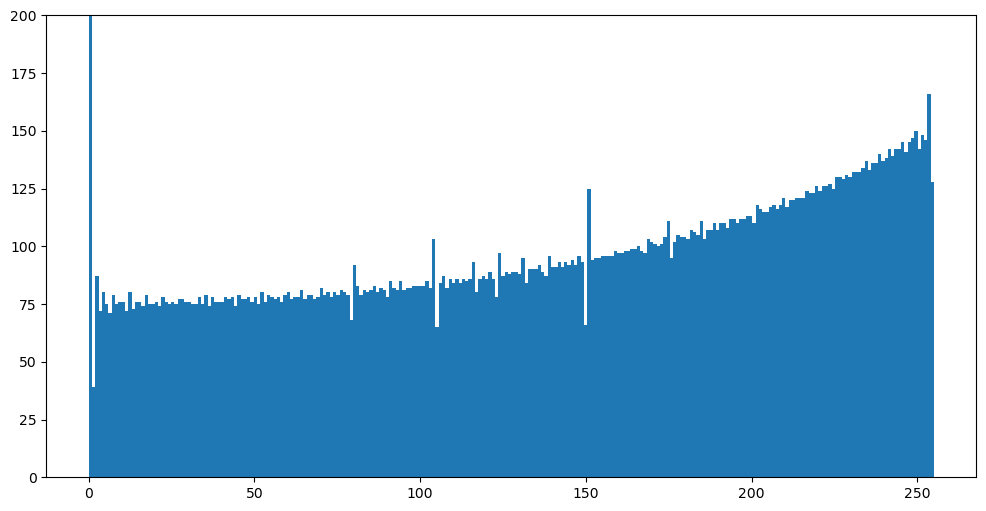

In [6]:
import numpy as np

data_w = 12
addr_w = 8
error_w = 8

rom_addr_w = addr_w * 2 - 1
rom_size = 1 << rom_addr_w

biggest_num = 2**addr_w - 1

file_name = "data/atan_rom.hex"

data = np.zeros(rom_size, dtype=float)
counter = 0
for big_num in range(2 ** (addr_w - 1), 2**addr_w):
    for small_num in range(2**addr_w):
        counter += 1
        if big_num >= small_num:
            data[(big_num - 2 ** (addr_w - 1)) * 2**addr_w + small_num] = np.arctan2(small_num, big_num) / np.pi * 4 * (2**error_w - 1)
            # print(big_num, small_num, np.arctan2(small_num, big_num) / np.pi * (2**error_w - 1))

# print(f"Total {counter} entries")
data = np.round(data).astype(np.int32)

print(data.min(), data.max())

np.savetxt(file_name, data, fmt="%X")

# print(np.argmax(data), np.max(data))

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(data, bins=2**error_w)
plt.ylim(0, 200)

plt.show()

In [ ]:
# 验证：随机采样
# np.random.seed(0)
N = 200000
xs = np.round(np.random.uniform(0, 2**data_w - 1, N)).astype((np.int32))
ys = np.round(np.random.uniform(0, 2**data_w - 1, N)).astype((np.int32))

for i in range(N):
    x = xs[i]
    y = ys[i]

    if y > x:
        xs[i], ys[i] = y, x


true_angles = np.arctan2(ys, xs)
approx_angles = np.zeros(N, dtype=float)

for i in range(N):
    x = xs[i]
    y = ys[i]

    # if y > x:
    #     x, y = y, x

    # print(f"x={x:012b}, y={y:012b}")

    # 前导0 计数
    lz = 0
    for bit in range(data_w - 1, -1, -1):
        if (x >> bit) & 1 == 0:
            lz += 1
        else:
            break

    # print(f"lz={lz}")

    x = x << lz
    y = y << lz
    # print(f"x={x:012b}, y={y:012b}")
    x = x >> (data_w - addr_w)
    y = y >> (data_w - addr_w)

    # print(f"x={x:012b}, y={y:012b}")
    # print(f"_____________________________")
    # x 截取低 addr_w 位
    x = x & (2 ** (addr_w - 1) - 1)
    # if i == 10:
    #     break

    addr = x * 2**addr_w + y
    approx_angles[i] = data[addr] / (2**error_w - 1) * np.pi / 4

# 误差（以度为单位，并把差值 wrap 到 [-180,180]）
errors = np.rad2deg(approx_angles - true_angles)
errors = (errors + 180.0) % 360.0 - 180.0
abs_err = np.abs(errors)

print("样本数:", N)
print("平均绝对误差 = {:.6f}°".format(np.mean(abs_err)))
print("最大绝对误差 = {:.6f}°".format(np.max(abs_err)))
print("中位数 (50%) = {:.6f}°".format(np.percentile(abs_err, 50)))
print("90 百分位 = {:.6f}°".format(np.percentile(abs_err, 90)))
print("99 百分位 = {:.6f}°".format(np.percentile(abs_err, 99)))

样本数: 200000
平均绝对误差 = 0.093274°
最大绝对误差 = 0.499284°
中位数 (50%) = 0.076305°
90 百分位 = 0.197368°
99 百分位 = 0.316592°


In [2]:
import numpy as np

theta = np.linspace(-np.pi, np.pi, 100)
complex_exps = np.exp(1j * theta) * 2000
reals = complex_exps.real.astype(np.int32)
imags = complex_exps.imag.astype(np.int32)

# print(np.array2string(reals, separator=', '))
# print(np.array2string(imags, separator=', '))


def get_verilog_init(array, name):
    lines = []
    lines.append("    initial begin")
    for i in range(len(array)):
        lines.append(f"        {name}[{i}] = {array[i]};")
    lines.append("    end")
    return "\n".join(lines)


print(get_verilog_init(reals, "x_ins"))
print(get_verilog_init(imags, "y_ins"))

    initial begin
        x_ins[0] = -2000;
        x_ins[1] = -1995;
        x_ins[2] = -1983;
        x_ins[3] = -1963;
        x_ins[4] = -1935;
        x_ins[5] = -1900;
        x_ins[6] = -1856;
        x_ins[7] = -1805;
        x_ins[8] = -1747;
        x_ins[9] = -1682;
        x_ins[10] = -1610;
        x_ins[11] = -1532;
        x_ins[12] = -1447;
        x_ins[13] = -1357;
        x_ins[14] = -1261;
        x_ins[15] = -1160;
        x_ins[16] = -1054;
        x_ins[17] = -944;
        x_ins[18] = -830;
        x_ins[19] = -713;
        x_ins[20] = -593;
        x_ins[21] = -471;
        x_ins[22] = -347;
        x_ins[23] = -221;
        x_ins[24] = -95;
        x_ins[25] = 31;
        x_ins[26] = 158;
        x_ins[27] = 284;
        x_ins[28] = 409;
        x_ins[29] = 532;
        x_ins[30] = 654;
        x_ins[31] = 772;
        x_ins[32] = 888;
        x_ins[33] = 1000;
        x_ins[34] = 1107;
        x_ins[35] = 1211;
        x_ins[36] = 1309;
        x_ins[37] = 140

# Generate Sine Rom

In [8]:
import numpy as np

addr_w = 8
data_w = 10
file_name = "data/sine_rom.hex"

data_w = data_w - 1
sin_rom = np.zeros(2**addr_w, dtype=int)
for i in range(2**addr_w):
    sin_rom[i] = np.round(np.sin(np.pi / 2 * (i + 0.5) / 2**addr_w) * (2**data_w - 1))

np.savetxt(file_name, sin_rom, fmt="%X")

In [9]:
sin_rom

array([  2,   5,   8,  11,  14,  17,  20,  24,  27,  30,  33,  36,  39,
        42,  45,  49,  52,  55,  58,  61,  64,  67,  70,  73,  77,  80,
        83,  86,  89,  92,  95,  98, 101, 104, 107, 110, 113, 117, 120,
       123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159,
       162, 165, 168, 171, 174, 177, 180, 182, 185, 188, 191, 194, 197,
       200, 203, 206, 209, 211, 214, 217, 220, 223, 226, 228, 231, 234,
       237, 239, 242, 245, 248, 251, 253, 256, 259, 261, 264, 267, 269,
       272, 275, 277, 280, 283, 285, 288, 290, 293, 296, 298, 301, 303,
       306, 308, 311, 313, 316, 318, 321, 323, 325, 328, 330, 333, 335,
       337, 340, 342, 344, 347, 349, 351, 353, 356, 358, 360, 362, 365,
       367, 369, 371, 373, 375, 378, 380, 382, 384, 386, 388, 390, 392,
       394, 396, 398, 400, 402, 404, 406, 408, 410, 411, 413, 415, 417,
       419, 420, 422, 424, 426, 427, 429, 431, 433, 434, 436, 437, 439,
       441, 442, 444, 445, 447, 448, 450, 451, 453, 454, 456, 45

# CORDIC TB

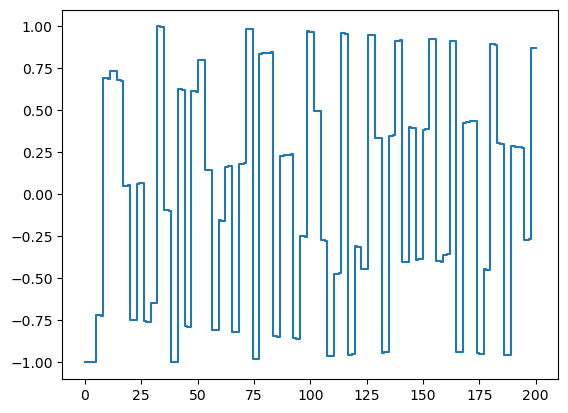

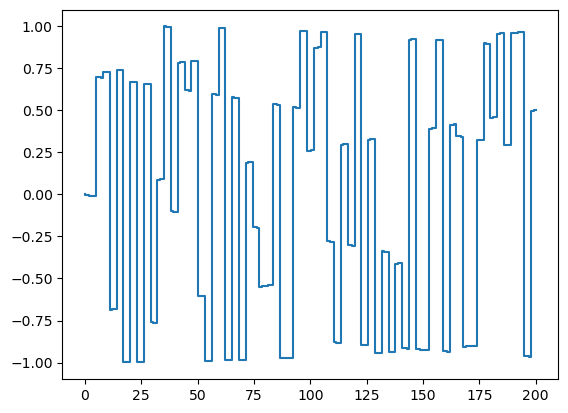

int32 -818 818


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.signal as signal
from scipy import interpolate


freq_baseband = 10_000_000  # 10 MHz
freq_delta_carrier = 52_000  # 100 kHz
# freq_delta_carrier = 0

freq_sampling_tx = 125_000_000  # 30 MHz
# freq_sampling_rx = 30_000_000 - 1000

# important
num_samples_tx = 30_000
sample_width = 12
# num_samples_rx = int(num_samples_tx * freq_sampling_rx / freq_sampling_tx)
# num_samples = 30

mpsk = 8
samples_per_bit = 3

# Generate random baseband signal
baseband_signal = np.array([random.randint(0, mpsk - 1) for _ in range(num_samples_tx)])
# baseband_signal = np.array([0, 2]* (num_samples_tx // 2))  # Example: alternating 0 and 2 for simplicity


# sampled tx signal
t = np.arange(num_samples_tx * samples_per_bit) / freq_sampling_tx
# repeated_baseband = baseband_signal[np.floor(t * freq_baseband).astype(int) % num_samples_tx]
repeated_baseband = np.repeat(baseband_signal, samples_per_bit)

tx_signal = np.exp(1j * 2 * np.pi * repeated_baseband / mpsk) * np.exp(1j * 2 * np.pi * freq_delta_carrier * t)

plt.step(np.linspace(0, 200, 200), tx_signal.real[:200], label="Real Part")
# plt.plot(tx_signal.imag[:200], label='Imaginary Part')
plt.show()

plt.step(np.linspace(0, 200, 200), tx_signal.imag[:200], label="Real Part")
# plt.plot(tx_signal.imag[:200], label='Imaginary Part')
plt.show()

tx_signal = tx_signal * (2 ** (sample_width - 1) - 1) * 0.4
# tx_signal = tx_signal.astype(np.int32)
real = tx_signal.real.astype(np.int32)
imag = tx_signal.imag.astype(np.int32)

print(real.dtype, real.min(), real.max())

# 补码
def get_twos_complement(array, bits):
    return np.where(array >= 0, array, (1 << bits) + array)


real = get_twos_complement(real, sample_width)
imag = get_twos_complement(imag, sample_width)

np.savetxt("../tb/tx_signal.hex", real * 2**sample_width + imag, fmt="%X")